In [1]:
from matplotlib.colors import ListedColormap
import glob, os, shutil, cv2, json, sys
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import numpy as np

In [2]:
BASE_PATH = '../Dataset/dataset3'

In [3]:
def getFiles(path, limit=None, shuffle=False):
    target = sorted(glob.glob(os.path.join(path, '*')))
    if shuffle:
        np.random.shuffle(target) 
    return target[:limit]

def setFolder(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)


OPTIONS = json.loads(open('../../Task/info.json', 'r').read())
OPTIONS['dataset'] = BASE_PATH.split('/')[-1].strip()
OPTIONS

{'network': 'segresnet',
 'dataset': 'dataset3',
 'img_size': None,
 'lr': 0.001,
 'loss': 'dice',
 'batch_size': 2,
 'scheduler': 'plateau',
 'dropout': 0.1,
 'num_filters': 32}

In [4]:
with open('../../Task/info.json', 'w', encoding='utf-8') as file:
    json.dump(OPTIONS, file, ensure_ascii=False, indent=4) 

# CONVERTENDO IMAGENS

In [5]:
os.listdir()

['Format.ipynb', 'original']

In [6]:
images = sorted(os.listdir('original/images'))
masks  = sorted(os.listdir('original/masks'))

print(images[0])
print(masks[0])

img_0000.npy
img_0000.npy


-4.1711364 5.3415837 -1.0477379e-09 0.99999994


 showing index 0


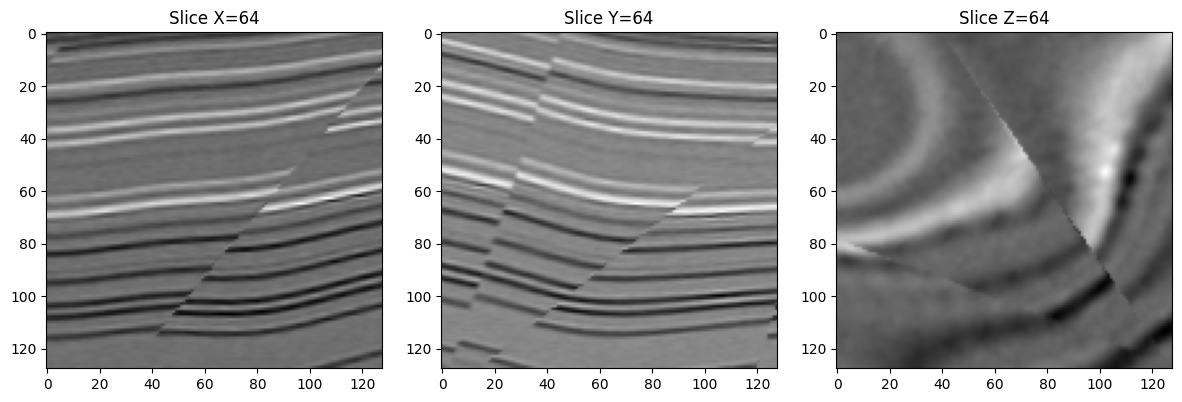

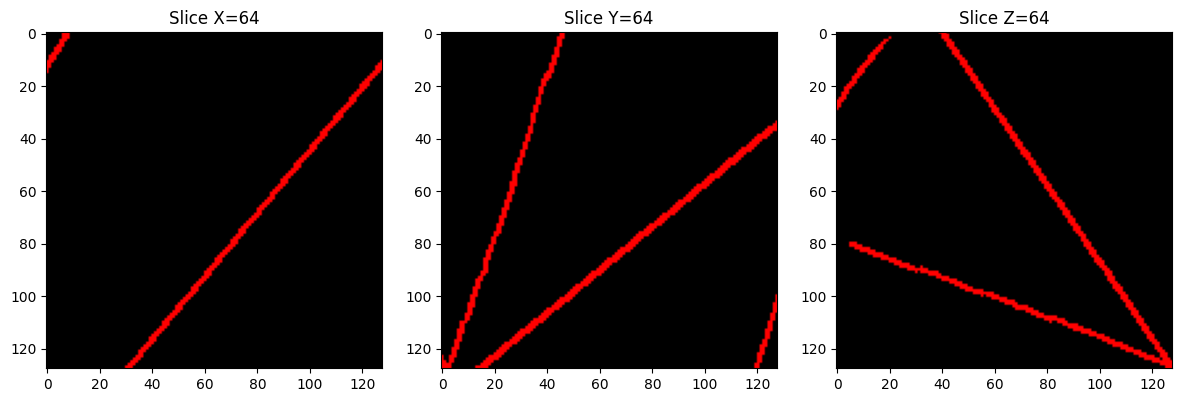

In [7]:
def formatAxis(img):
    return np.transpose(img, (0, 1, 2))

def showTile(img, mask=False):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    mid_x = img.shape[0] // 2
    mid_y = img.shape[1] // 2
    mid_z = img.shape[2] // 2

    slices = [
        img[mid_x, :, :],  # Plano YZ (Corte ao longo do eixo X)
        img[:, mid_y, :],  # Plano XZ (Corte ao longo do eixo Y)
        img[:, :, mid_z]   # Plano XY (Corte ao longo do eixo Z)
    ]

    slices[0] = np.array(slices[0])
    arr_y = np.array(slices[1])
    arr_z = np.array(slices[2])
    slices[1] = np.rot90(arr_z, -1)
    slices[2] = arr_y

    cmap_config = ListedColormap(['black', 'red', 'green', 'blue']) if mask else 'gray'
    vmin, vmax  = (0, 3) if mask else (None, None)
    titles = [f'Slice X={mid_x}', f'Slice Y={mid_y}', f'Slice Z={mid_z}']
    
    for i, ax in enumerate(axes):
        ax.imshow(slices[i], cmap=cmap_config, vmin=vmin, vmax=vmax)
        ax.set_title(titles[i])
    
    plt.tight_layout()
    plt.show()

def getImage(base_path, file_name):
    return formatAxis(np.load(os.path.join(base_path, file_name)))

for i, (img_path, msk_path) in enumerate(zip(images, masks)):
    if i == 1:
        break

    img = getImage('original/images', img_path)
    print(np.min(img), np.max(img), np.mean(img), np.std(img))
    
    print(f'\n\n showing index {i}')
    showTile(getImage('original/images', img_path), mask=False)
    showTile(getImage('original/masks',  msk_path), mask=True)

In [8]:
setFolder('images')
setFolder('masks')

for img_path, msk_path in tqdm(zip(images, masks), total=len(images)):
    np.save(os.path.join('images', img_path), getImage('original/images', img_path))
    np.save(os.path.join('masks', msk_path),  getImage('original/masks',  msk_path))

images = getFiles('images')
masks  = getFiles('masks')

print(images[0])
print(masks[0])

100%|██████████| 220/220 [00:01<00:00, 194.00it/s]

images/img_0000.npy
masks/img_0000.npy


In [9]:
df = pd.DataFrame()
df['img_path']  = [os.path.join(BASE_PATH, path) for path in images]
df['mask_path'] = [os.path.join(BASE_PATH, path) for path in masks]
df['shape'] = [np.load(path).shape for path in getFiles('images')]
df

,img_path,mask_path,shape
0,../Dataset/dataset3/images/img_0000.npy,../Dataset/dataset3/masks/img_0000.npy,"(128, 128, 128)"
1,../Dataset/dataset3/images/img_0001.npy,../Dataset/dataset3/masks/img_0001.npy,"(128, 128, 128)"
2,../Dataset/dataset3/images/img_0002.npy,../Dataset/dataset3/masks/img_0002.npy,"(128, 128, 128)"
3,../Dataset/dataset3/images/img_0003.npy,../Dataset/dataset3/masks/img_0003.npy,"(128, 128, 128)"
4,../Dataset/dataset3/images/img_0004.npy,../Dataset/dataset3/masks/img_0004.npy,"(128, 128, 128)"
...,...,...,...
215,../Dataset/dataset3/images/img_0215.npy,../Dataset/dataset3/masks/img_0215.npy,"(128, 128, 128)"
216,../Dataset/dataset3/images/img_0216.npy,../Dataset/dataset3/masks/img_0216.npy,"(128, 128, 128)"
217,../Dataset/dataset3/images/img_0217.npy,../Dataset/dataset3/masks/img_0217.npy,"(128, 128, 128)"
218,../Dataset/dataset3/images/img_0218.npy,../Dataset/dataset3/masks/img_0218.npy,"(128, 128, 128)"


In [10]:
if OPTIONS.get('img_size') is None:
    df.to_csv('../DataBase.csv', index=None)
    display(df)
    sys.exit("Finalizando o programa: sem tiles nessa rodada")

,img_path,mask_path,shape
0,../Dataset/dataset3/images/img_0000.npy,../Dataset/dataset3/masks/img_0000.npy,"(128, 128, 128)"
1,../Dataset/dataset3/images/img_0001.npy,../Dataset/dataset3/masks/img_0001.npy,"(128, 128, 128)"
2,../Dataset/dataset3/images/img_0002.npy,../Dataset/dataset3/masks/img_0002.npy,"(128, 128, 128)"
3,../Dataset/dataset3/images/img_0003.npy,../Dataset/dataset3/masks/img_0003.npy,"(128, 128, 128)"
4,../Dataset/dataset3/images/img_0004.npy,../Dataset/dataset3/masks/img_0004.npy,"(128, 128, 128)"
...,...,...,...
215,../Dataset/dataset3/images/img_0215.npy,../Dataset/dataset3/masks/img_0215.npy,"(128, 128, 128)"
216,../Dataset/dataset3/images/img_0216.npy,../Dataset/dataset3/masks/img_0216.npy,"(128, 128, 128)"
217,../Dataset/dataset3/images/img_0217.npy,../Dataset/dataset3/masks/img_0217.npy,"(128, 128, 128)"
218,../Dataset/dataset3/images/img_0218.npy,../Dataset/dataset3/masks/img_0218.npy,"(128, 128, 128)"


SystemExit: Finalizando o programa: sem tiles nessa rodada

/home/grva-mint/anaconda3/envs/torch-gpu/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# TILES

In [ ]:
IMG_SIZE = tuple(OPTIONS['img_size'])
IMG_SIZE

(125, 128, 128)

In [ ]:
class TilesBuilder:
    def __init__(self, target_size=(8, 64, 128), main_dir='tiles'):
        self.target_size = target_size
        self.main_dir    = main_dir

        if os.path.exists(main_dir):
            shutil.rmtree(main_dir)
        os.makedirs(main_dir)

    def update(self, file_path, target_dir, is_mask=False):
        folder = os.path.join(self.main_dir, target_dir)
        os.makedirs(folder, exist_ok=True)
        data = np.load(file_path)

        base_name     = os.path.splitext(os.path.basename(file_path))[0]
        z_t, y_t, x_t = self.target_size
        
        z_pad = (z_t - data.shape[0] % z_t) % z_t
        y_pad = (y_t - data.shape[1] % y_t) % y_t
        x_pad = (x_t - data.shape[2] % x_t) % x_t

        pad_mode    = 'constant' if is_mask else 'reflect'
        data_padded = np.pad(data, ((0, z_pad), (0, y_pad), (0, x_pad)), mode=pad_mode) if z_pad > 0 or y_pad > 0 or x_pad > 0 else data
            
        index = 0
        for z in range(0, data_padded.shape[0], z_t):
            for y in range(0, data_padded.shape[1], y_t):
                for x in range(0, data_padded.shape[2], x_t):
                    tile = data_padded[z:z+z_t, y:y+y_t, x:x+x_t]
                    save_path = os.path.join(folder, f'{base_name}_tile_{index}.npy')
                    
                    np.save(save_path, tile)
                    index = (index + 1)


tiles = TilesBuilder(target_size=IMG_SIZE, main_dir='tiles')
for img_path, mask_path in tqdm(zip(images, masks), total=len(df)):
    tiles.update(img_path,  'images/', is_mask=False)
    tiles.update(mask_path, 'masks/',  is_mask=True)

100%|██████████| 50/50 [00:00<00:00, 99.01it/s]


In [ ]:
print(len(getFiles('tiles/images')), 'imagens geradas')

100 imagens geradas


In [ ]:
df = pd.DataFrame()
df['img_path']  = [os.path.join(BASE_PATH, path) for path in getFiles('tiles/images')]
df['mask_path'] = [os.path.join(BASE_PATH, path) for path in getFiles('tiles/masks')]
df['shape'] = [tiles.target_size for _ in range(len(df))]

df.to_csv('../DataBase.csv', index=None)
df

,img_path,mask_path,shape
0,../Dataset/dataset3/tiles/images/img_0000_tile...,../Dataset/dataset3/tiles/masks/img_0000_tile_...,"(125, 128, 128)"
1,../Dataset/dataset3/tiles/images/img_0000_tile...,../Dataset/dataset3/tiles/masks/img_0000_tile_...,"(125, 128, 128)"
2,../Dataset/dataset3/tiles/images/img_0001_tile...,../Dataset/dataset3/tiles/masks/img_0001_tile_...,"(125, 128, 128)"
3,../Dataset/dataset3/tiles/images/img_0001_tile...,../Dataset/dataset3/tiles/masks/img_0001_tile_...,"(125, 128, 128)"
4,../Dataset/dataset3/tiles/images/img_0002_tile...,../Dataset/dataset3/tiles/masks/img_0002_tile_...,"(125, 128, 128)"
...,...,...,...
95,../Dataset/dataset3/tiles/images/img_0047_tile...,../Dataset/dataset3/tiles/masks/img_0047_tile_...,"(125, 128, 128)"
96,../Dataset/dataset3/tiles/images/img_0048_tile...,../Dataset/dataset3/tiles/masks/img_0048_tile_...,"(125, 128, 128)"
97,../Dataset/dataset3/tiles/images/img_0048_tile...,../Dataset/dataset3/tiles/masks/img_0048_tile_...,"(125, 128, 128)"
98,../Dataset/dataset3/tiles/images/img_0049_tile...,../Dataset/dataset3/tiles/masks/img_0049_tile_...,"(125, 128, 128)"
